In [1]:
from pathlib import Path

import anndata as ad
import pooch
import scanpy as sc
from rich import print

sc.settings.set_figure_params(dpi=50, facecolor="white")


In [2]:
download_dir = Path("/home/liuc9/tmp/scanpy")

samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}


for sample_id, filename in samples.items():
    print(download_dir / filename)
    sample_adata = sc.read_10x_h5(download_dir / filename)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata.var
adata


/home/liuc9/tmp/scanpy/s1d1_filtered_feature_bc_matrix.h5

/home/liuc9/tools/anaconda3/envs/renv/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/liuc9/tools/anaconda3/envs/renv/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/liuc9/tmp/scanpy/s1d3_filtered_feature_bc_matrix.h5

/home/liuc9/tools/anaconda3/envs/renv/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/liuc9/tools/anaconda3/envs/renv/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/liuc9/tools/anaconda3/envs/renv/lib/python3.13/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64

AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

# Quality Control

In [3]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")


In [4]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)


In [5]:
adata

AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

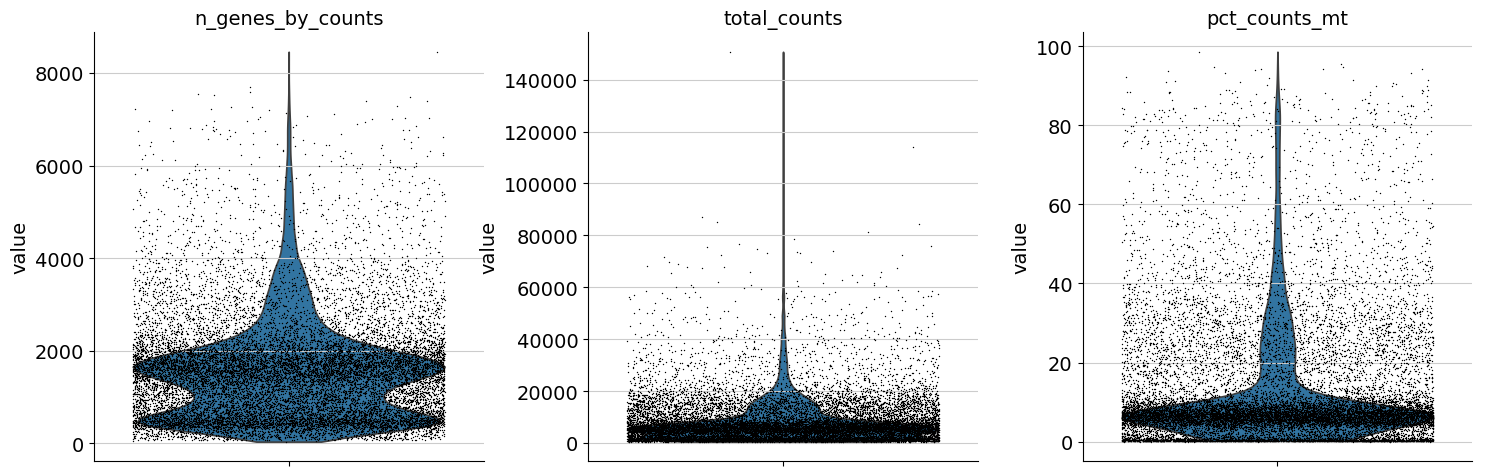

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


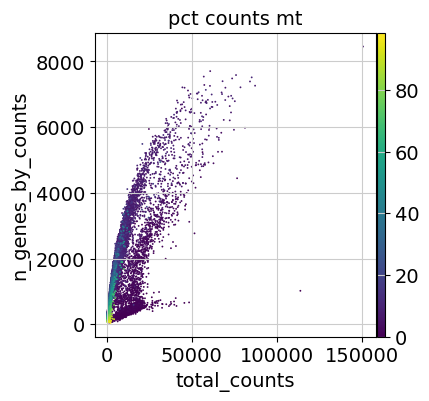

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")


In [8]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)


# Doublet detection


In [9]:
sc.pp.scrublet(adata, batch_key="sample")


# Normalization

In [10]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Feature selection

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")


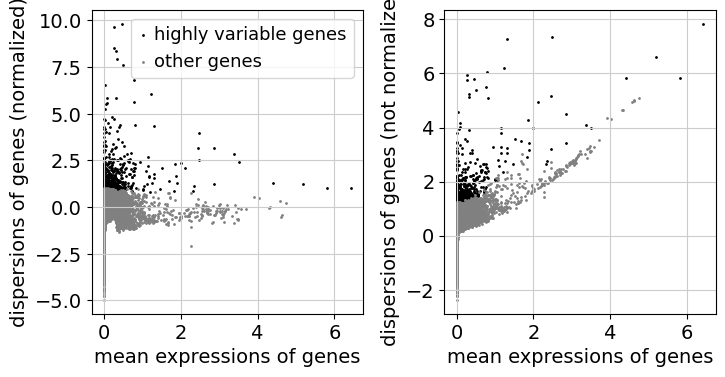

In [12]:
sc.pl.highly_variable_genes(adata)


# Dimensionality Reduction

In [13]:
sc.tl.pca(adata)


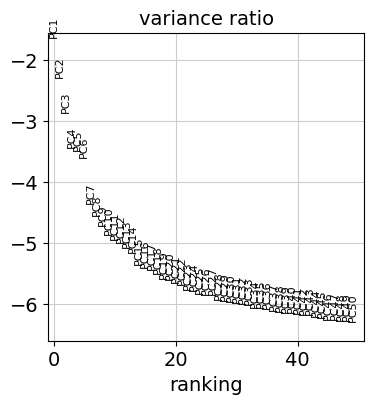

In [14]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)


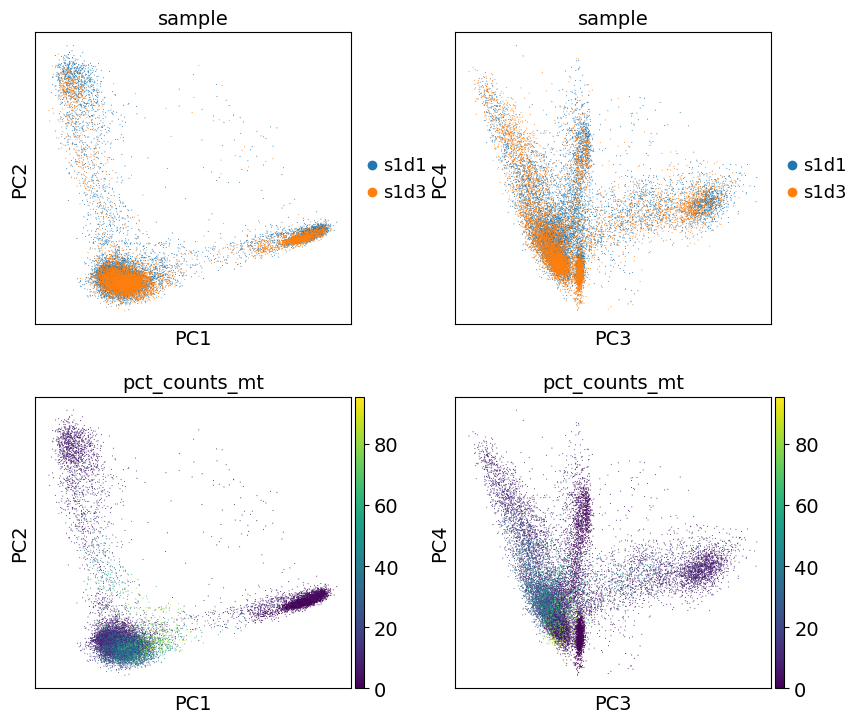

In [15]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)


# Nearest neighbor graph constuction and visualization#

In [16]:
sc.pp.neighbors(adata)


/home/liuc9/tools/anaconda3/envs/renv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
sc.tl.umap(adata)


In [20]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet
AAACCCAAGGATGGCT-1,s1d1,2103,7.651596,8663.0,9.066932,42.721921,59.667552,69.744892,79.348955,460.0,...,5.309938,3650.0,8.202757,42.133209,17.0,2.890372,0.196237,2103,0.036113,False
AAACCCAAGGCCTAGA-1,s1d1,3916,8.273081,12853.0,9.461411,35.843772,44.262040,52.376877,62.763557,1790.0,...,13.926710,1719.0,7.450079,13.374310,58.0,4.077538,0.451257,3912,0.183381,False
AAACCCAAGTGAGTGC-1,s1d1,683,6.527958,1631.0,7.397562,56.284488,62.599632,70.386266,88.779890,581.0,...,35.622318,63.0,4.158883,3.862661,13.0,2.639057,0.797057,683,0.045320,False
AAACCCACAAGAGGCT-1,s1d1,4330,8.373554,17345.0,9.761117,27.662150,38.420294,48.901701,62.023638,780.0,...,4.496973,3936.0,8.278174,22.692417,44.0,3.806663,0.253675,4328,0.045320,False
AAACCCACATCGTGGC-1,s1d1,325,5.786897,555.0,6.320768,49.909910,59.459459,77.477477,100.000000,159.0,...,28.648647,26.0,3.295837,4.684685,26.0,3.295837,4.684685,323,0.016181,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGAGAGTCTGG-1,s1d3,277,5.627621,615.0,6.423247,63.089431,71.219512,87.479675,100.000000,282.0,...,45.853661,35.0,3.583519,5.691057,20.0,3.044523,3.252032,277,0.031161,False
TTTGTTGCAGACAATA-1,s1d3,3797,8.242230,13218.0,9.489410,30.753518,44.628537,53.691935,64.684521,864.0,...,6.536541,3997.0,8.293550,30.239067,42.0,3.761200,0.317749,3795,0.078619,False
TTTGTTGCATGTTACG-1,s1d3,3089,8.035926,27280.0,10.213945,64.409824,71.671554,78.317449,85.054985,1025.0,...,3.757332,3562.0,8.178358,13.057184,13145.0,9.483872,48.185482,3087,0.033898,False
TTTGTTGGTAGTCACT-1,s1d3,379,5.940171,698.0,6.549651,52.865330,60.028653,74.355301,100.000000,143.0,...,20.487106,58.0,4.077538,8.309455,39.0,3.688879,5.587393,379,0.039080,False


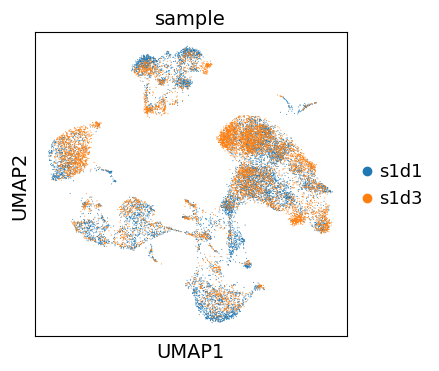

In [18]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)


# Clustering

In [21]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)


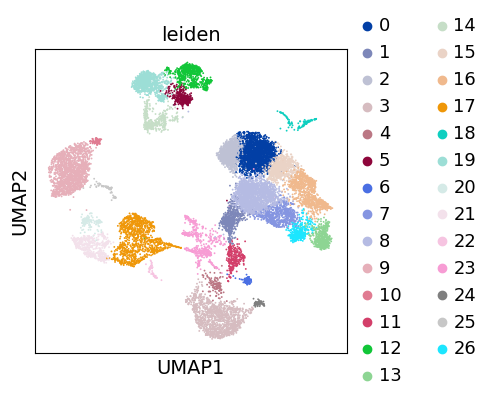

In [22]:
sc.pl.umap(adata, color=["leiden"])


# Re-assess quality control and cell filtering

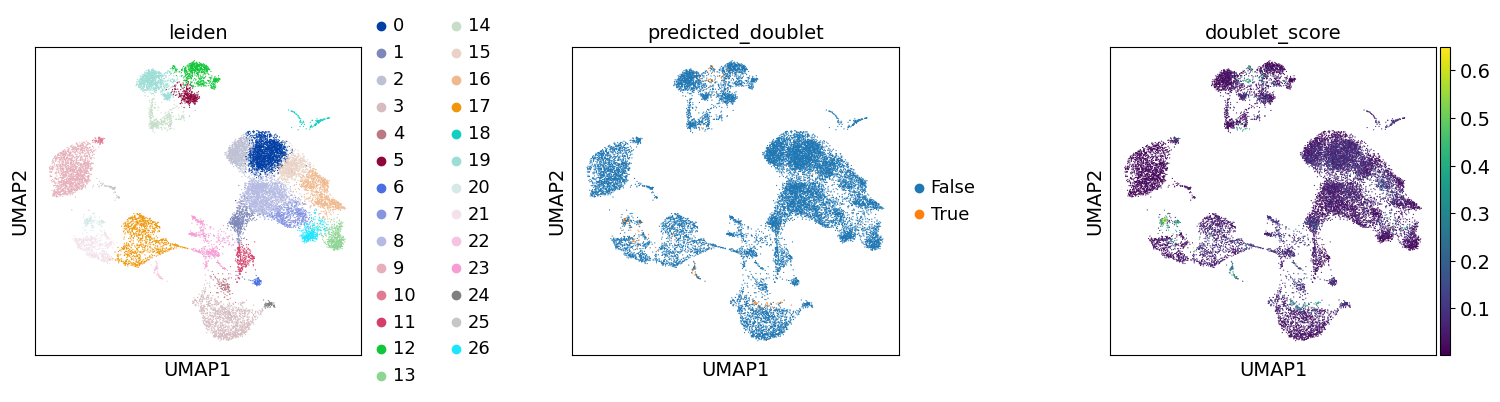

In [23]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)


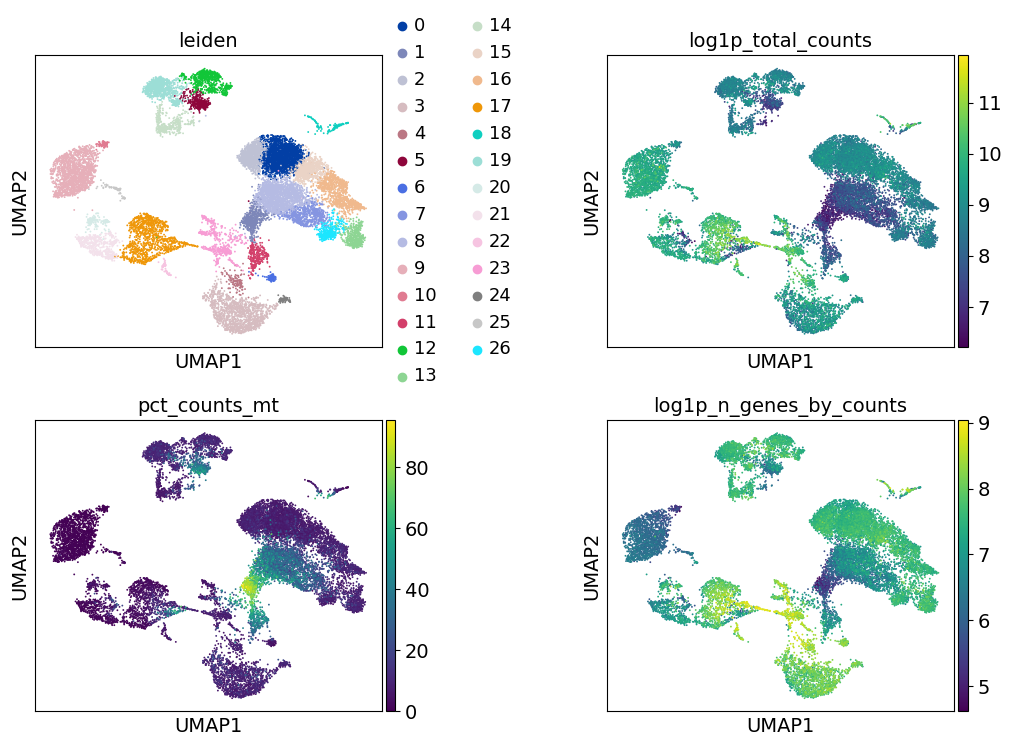

In [24]:
sc.pl.umap(
    adata,
    color=[
        "leiden",
        "log1p_total_counts",
        "pct_counts_mt",
        "log1p_n_genes_by_counts",
    ],
    wspace=0.5,
    ncols=2,
)


# Manual cell-type annotation

In [25]:
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        adata,
        key_added=f"leiden_res_{res:4.2f}",
        resolution=res,
        flavor="igraph",
    )


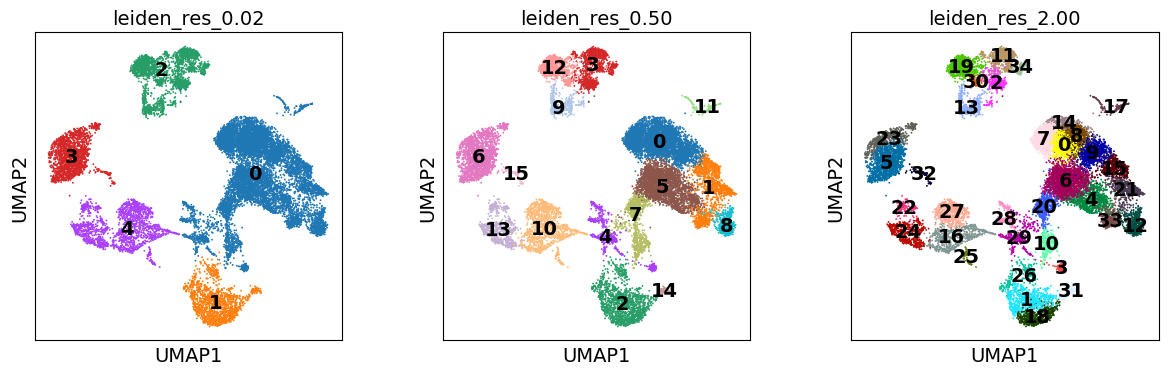

In [26]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)


# Marker gene set

In [27]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}


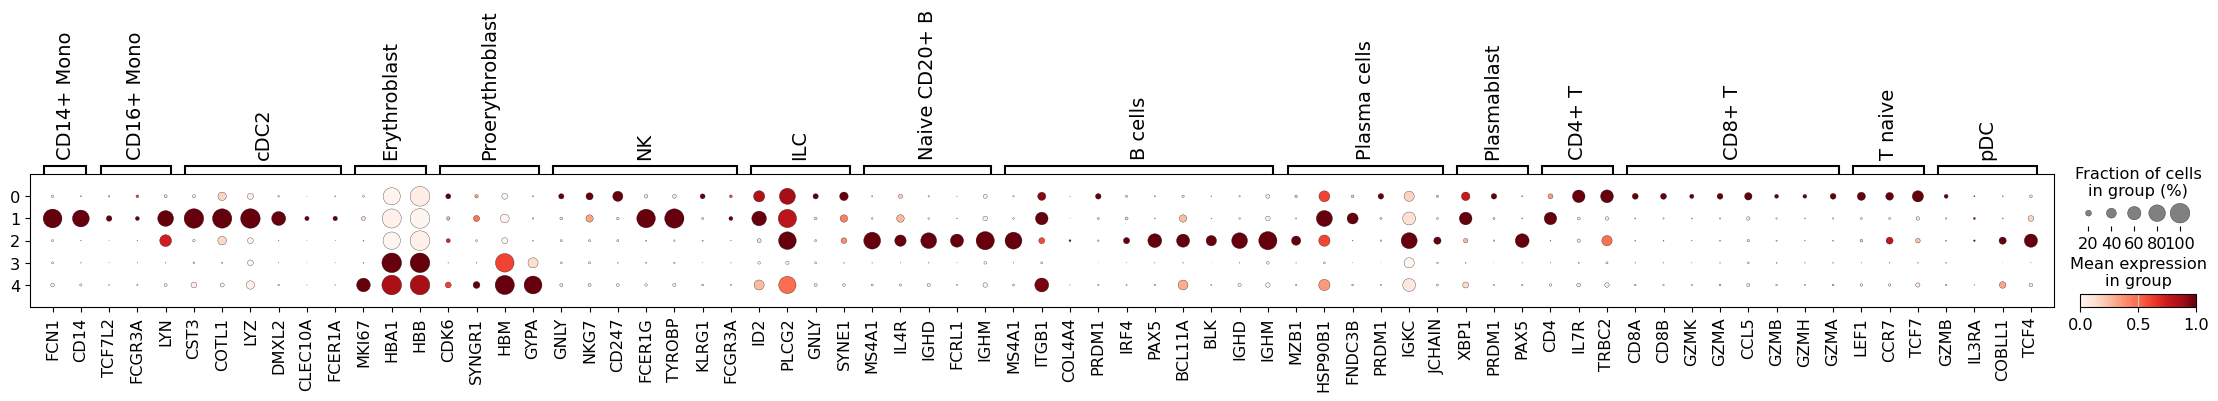

In [28]:
sc.pl.dotplot(
    adata, marker_genes, groupby="leiden_res_0.02", standard_scale="var"
)


In [29]:
adata.obs["cell_type_lvl1"] = adata.obs["leiden_res_0.02"].map(
    {
        "0": "Lymphocytes",
        "1": "Monocytes",
        "2": "Erythroid",
        "3": "B Cells",
    }
)


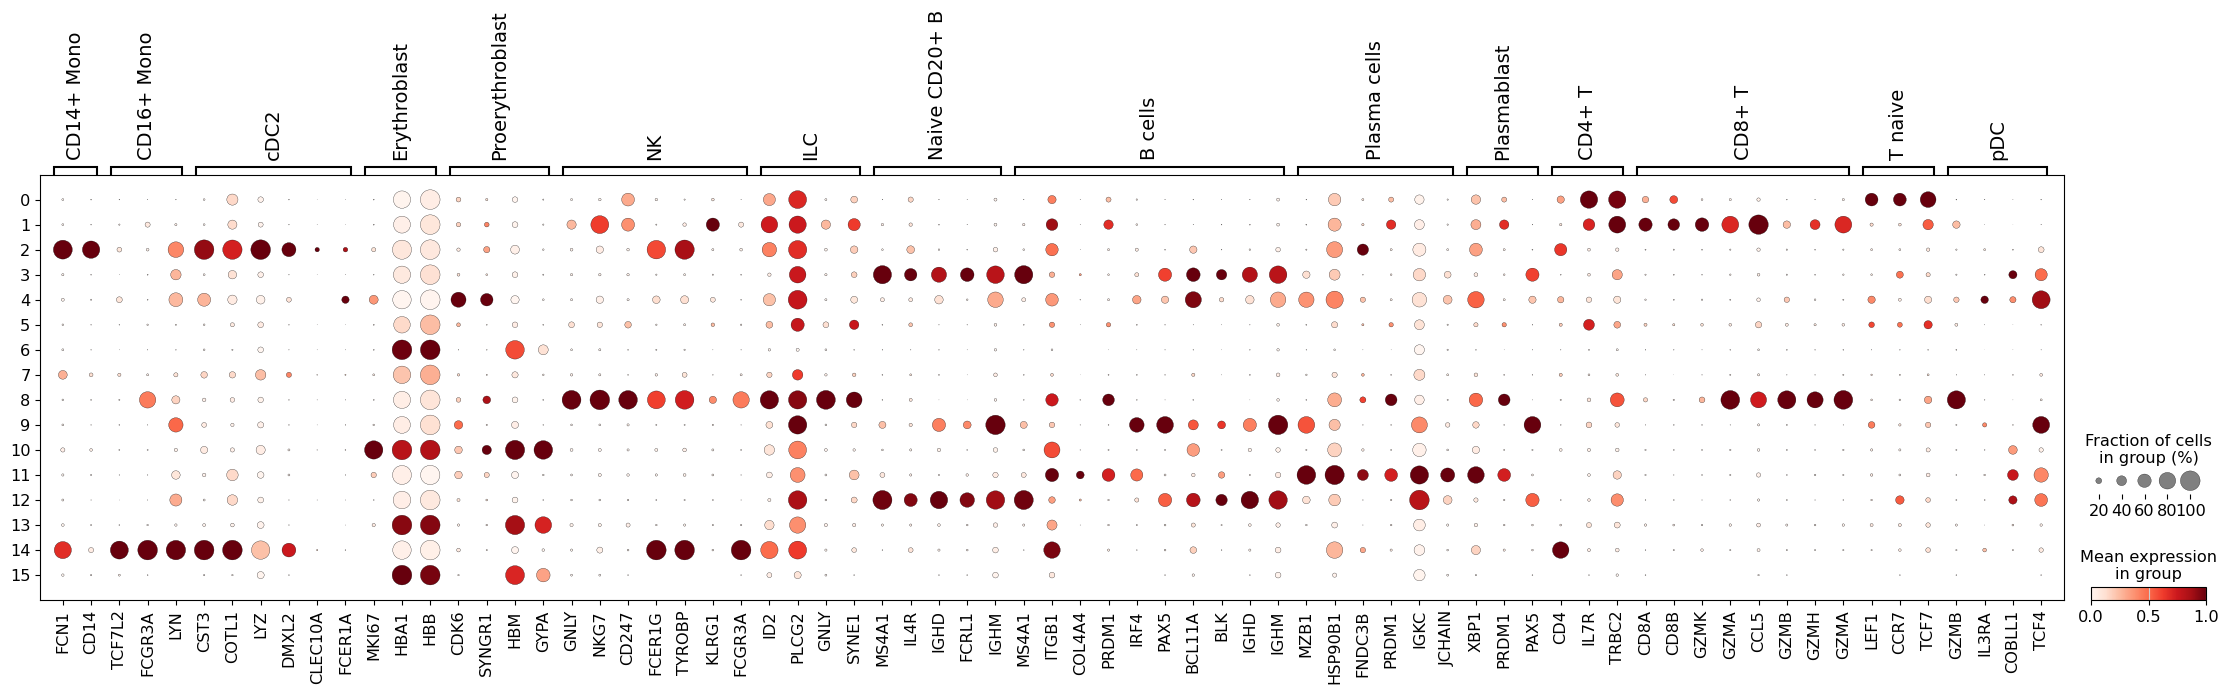

In [30]:
sc.pl.dotplot(
    adata, marker_genes, groupby="leiden_res_0.50", standard_scale="var"
)


# Differentially-expressed Genes as Markers

In [31]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")


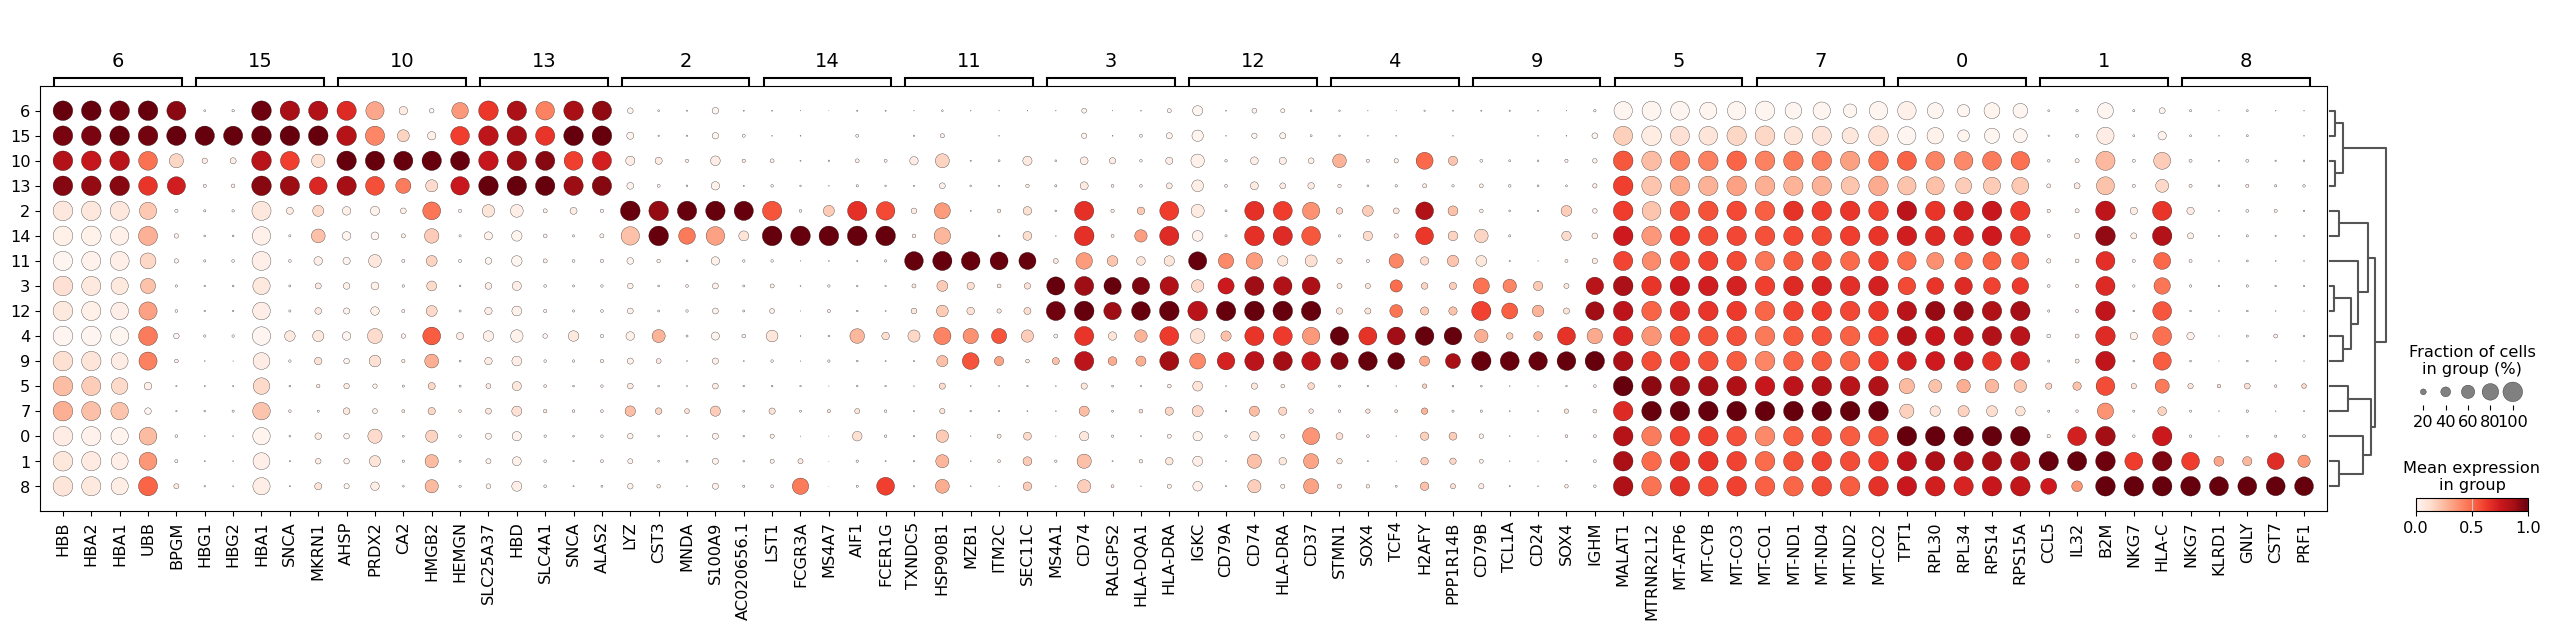

In [32]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden_res_0.50", standard_scale="var", n_genes=5
)


In [33]:
sc.get.rank_genes_groups_df(adata, group="7").head(5)


,names,scores,logfoldchanges,pvals,pvals_adj
0,MT-CO1,46.745182,3.227634,0.0,0.0
1,MT-ND1,46.499100,3.344352,0.0,0.0
2,MT-ND4,46.091423,3.111574,0.0,0.0
3,MT-ND2,46.042362,3.329867,0.0,0.0
4,MT-CO2,46.004745,3.210372,0.0,0.0


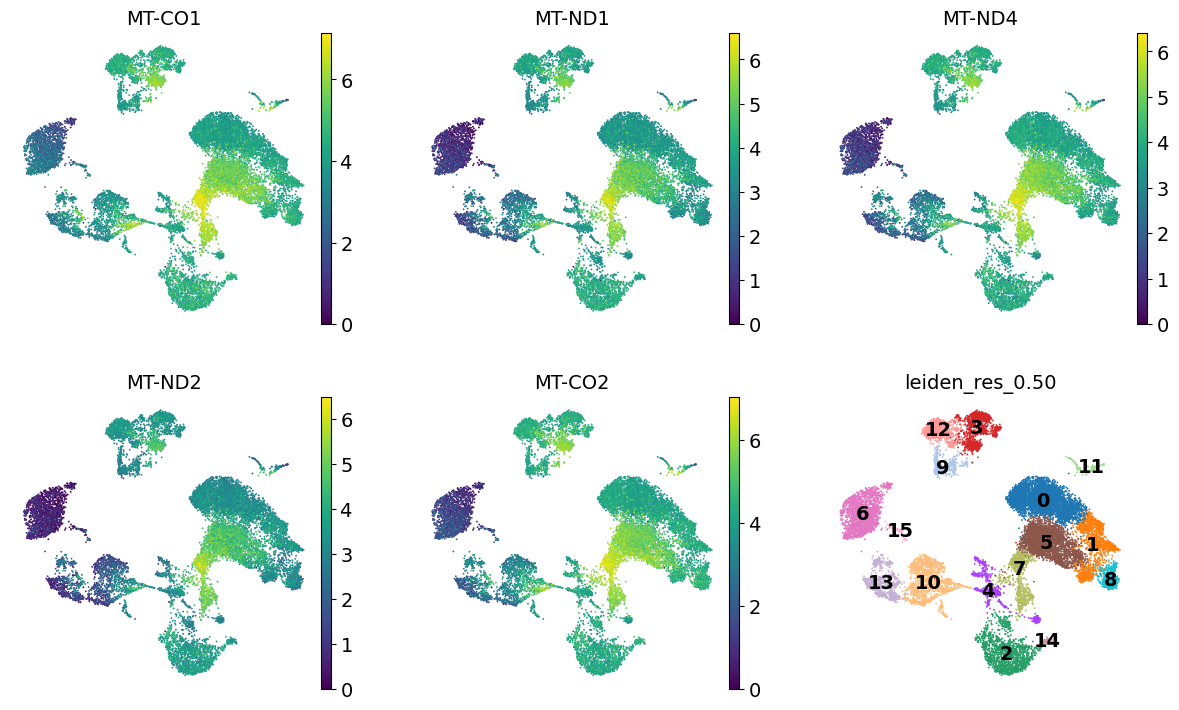

In [34]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)[
    "names"
]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)
